In [ ]:
pip install datasets

In [ ]:
from huggingface_hub import login

In [ ]:
login("")

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "conceptual_captions",
    split="train"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

unlabeled/train-00000-of-00002.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

unlabeled/train-00001-of-00002.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

unlabeled/validation-00000-of-00001.parq(…):   0%|          | 0.00/1.77M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3318333 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/15840 [00:00<?, ? examples/s]

In [ ]:
from itertools import islice

In [ ]:
sample = list(islice(dataset, 100000))

In [ ]:
objects = [
    "polar bear", "chalkboard", "banana",
    "apple", "dog", "chair", "flower", "shoe",
    "bag", "frog", "ball", "car"
]

colors = [
    "blue", "yellow", "red",
    "green", "pink", "orange",
    "purple", "white", "black"
]

In [ ]:
!pip install datasets seaborn pandas matplotlib -q

In [ ]:
from collections import defaultdict
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
def contains_word(text, word):
    return re.search(rf"\b{word}\b", text) is not None

def object_color_pair(text, obj, color):
    verbs = ["is", "are", "looks", "look", "appears", "seems"]
    verb_pattern = "|".join(verbs)

    pattern1 = rf"\b{color}\s+{obj}\b"

    pattern2 = rf"\b{obj}\s+(?:{verb_pattern})\s+{color}\b"

    pattern3 = rf"\b{obj}\b(?:\s+\w+){{0,2}}\s+{color}\b"

    return (
        re.search(pattern1, text) or
        re.search(pattern2, text) or
        re.search(pattern3, text)
    ) is not None

In [ ]:
counts_base = defaultdict(lambda: defaultdict(int)) # quantas vezes objeto + cor aparecem juntos
object_counts_base = defaultdict(int) ## quantas vezes cada objeto aparece

counts_pattern = defaultdict(lambda: defaultdict(int))
object_counts_pattern = defaultdict(int)

Teste: yellow banana on a pink background .

=== DEBUG ===
object_counts_base: {'dog': 1731, 'car': 2464, 'ball': 2191, 'flower': 950, 'apple': 207, 'frog': 113, 'shoe': 89, 'polar bear': 68, 'chalkboard': 52, 'chair': 380, 'bag': 390, 'banana': 86}
counts_base sample: {'flower': defaultdict(<class 'int'>, {'yellow': 63, 'white': 94, 'blue': 36, 'red': 42, 'pink': 58, 'black': 31, 'purple': 37, 'green': 23, 'orange': 13}), 'shoe': defaultdict(<class 'int'>, {'pink': 2, 'black': 3, 'white': 4, 'blue': 2, 'green': 1})}


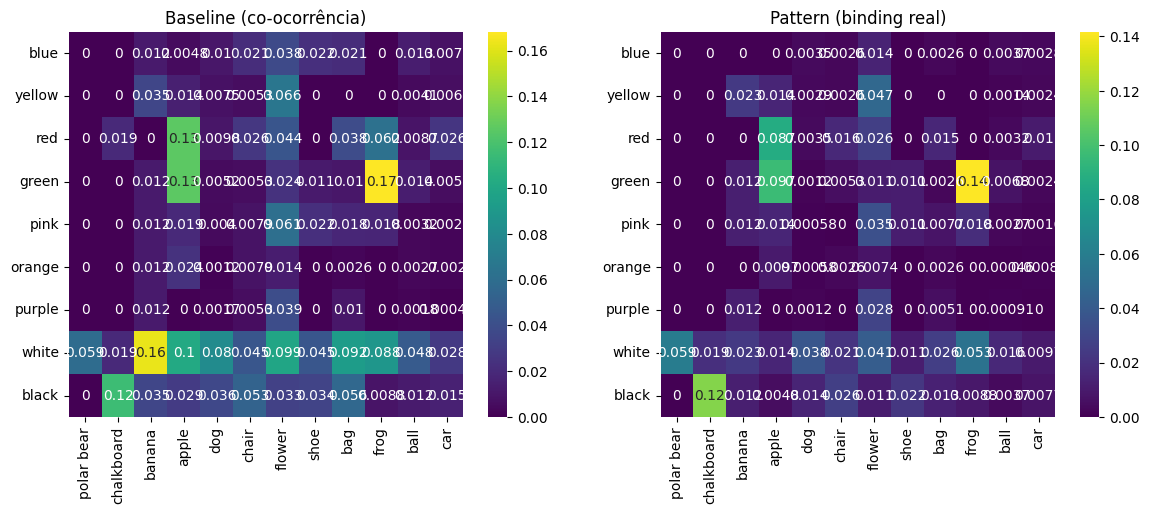

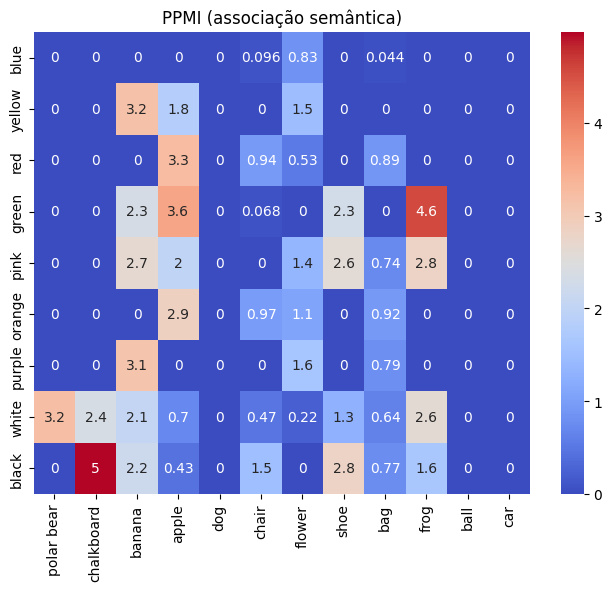

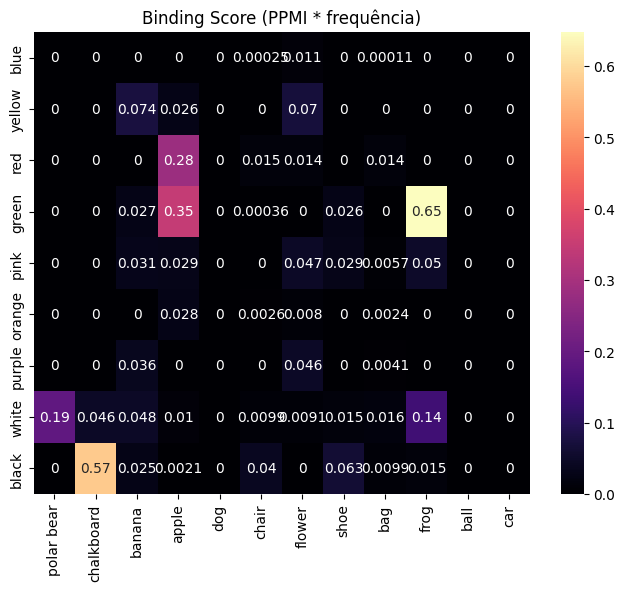


Global Binding Score (PPMI weighted): 0.0286

=== polar bear ===
blue: b=0.000 | p=0.000 | s=0.000 | gap=0.000 | ppmi=0.000 | score=0.0000
yellow: b=0.000 | p=0.000 | s=0.000 | gap=0.000 | ppmi=0.000 | score=0.0000
red: b=0.000 | p=0.000 | s=0.000 | gap=0.000 | ppmi=0.000 | score=0.0000
green: b=0.000 | p=0.000 | s=0.000 | gap=0.000 | ppmi=0.000 | score=0.0000
pink: b=0.000 | p=0.000 | s=0.000 | gap=0.000 | ppmi=0.000 | score=0.0000
orange: b=0.000 | p=0.000 | s=0.000 | gap=0.000 | ppmi=0.000 | score=0.0000
purple: b=0.000 | p=0.000 | s=0.000 | gap=0.000 | ppmi=0.000 | score=0.0000
white: b=0.059 | p=0.059 | s=1.000 | gap=0.000 | ppmi=3.219 | score=0.1893
black: b=0.000 | p=0.000 | s=0.000 | gap=0.000 | ppmi=0.000 | score=0.0000

=== chalkboard ===
blue: b=0.000 | p=0.000 | s=0.000 | gap=0.000 | ppmi=0.000 | score=0.0000
yellow: b=0.000 | p=0.000 | s=0.000 | gap=0.000 | ppmi=0.000 | score=0.0000
red: b=0.019 | p=0.000 | s=0.000 | gap=0.019 | ppmi=0.000 | score=0.0000
green: b=0.000 | 

In [ ]:
import math

N = 200_000
teste = []

for sample in dataset.select(range(N)):
    caption = sample["caption"]

    if caption is None:
        continue

    if contains_word(caption, "banana") and contains_word(caption, "pink"):
        teste.append(caption)

    caption = caption.lower()

    for obj in objects:
        if contains_word(caption, obj):

            # ===== BASELINE =====
            object_counts_base[obj] += 1

            for color in colors:
                if contains_word(caption, color):
                    counts_base[obj][color] += 1

            # ===== PATTERN =====
            object_counts_pattern[obj] += 1

            for color in colors:
                if object_color_pair(caption, obj, color):
                    counts_pattern[obj][color] += 1

for t in teste:
    print(f"Teste: {t}")

print("\n=== DEBUG ===")
print("object_counts_base:", dict(object_counts_base))
print("counts_base sample:", dict(list(counts_base.items())[:2]))

def compute_probabilities(counts, object_counts):
    probs = {}

    for obj in objects:
        total = object_counts[obj]

        if total == 0:
            continue

        probs[obj] = {
            color: counts[obj][color] / total
            for color in colors
        }

    return probs


probs_base = compute_probabilities(counts_base, object_counts_base)
probs_pattern = compute_probabilities(counts_pattern, object_counts_pattern)


# =========================
# DATAFRAMES
# =========================

df_base = pd.DataFrame(probs_base).fillna(0)
df_pattern = pd.DataFrame(probs_pattern).fillna(0)


# =========================
# HEATMAPS BASELINE vs PATTERN
# =========================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(df_base, annot=True, cmap="viridis")
plt.title("Baseline (co-ocorrência)")

plt.subplot(1, 2, 2)
sns.heatmap(df_pattern, annot=True, cmap="viridis")
plt.title("Pattern (binding real)")

plt.show()


# =========================
# BINDING (ANTIGOS)
# =========================

binding_strength = {}
binding_gap = {}

for obj in objects:
    binding_strength[obj] = {}
    binding_gap[obj] = {}

    for color in colors:
        b = probs_base.get(obj, {}).get(color, 0)
        p = probs_pattern.get(obj, {}).get(color, 0)

        binding_strength[obj][color] = (p / b) if b > 0 else 0
        binding_gap[obj][color] = b - p


binding_weighted = {}

for obj in objects:
    binding_weighted[obj] = {}

    for color in colors:
        p = probs_pattern.get(obj, {}).get(color, 0)
        binding_weighted[obj][color] = p

# total de objetos (aproximação de P(obj))
total_objects = sum(object_counts_pattern.values())

P_obj = {
    obj: object_counts_pattern[obj] / total_objects
    for obj in objects if total_objects > 0
}

# contagem global de cores
color_counts = {color: 0 for color in colors}

for obj in objects:
    for color in colors:
        color_counts[color] += counts_pattern[obj][color]

total_colors = sum(color_counts.values())

P_color = {
    color: color_counts[color] / total_colors
    for color in colors if total_colors > 0
}

# cálculo do PPMI e score final
binding_ppmi = {}
binding_score = {}

for obj in objects:
    binding_ppmi[obj] = {}
    binding_score[obj] = {}

    for color in colors:
        p = probs_pattern.get(obj, {}).get(color, 0)

        if p == 0:
            ppmi = 0
        else:
            denom = P_obj.get(obj, 0) * P_color.get(color, 0)

            if denom > 0:
                ppmi = max(0, math.log(p / denom))
            else:
                ppmi = 0

        binding_ppmi[obj][color] = ppmi
        binding_score[obj][color] = p * ppmi


# =========================
# HEATMAP PPMI
# =========================

df_ppmi = pd.DataFrame(binding_ppmi).fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(df_ppmi, annot=True, cmap="coolwarm")
plt.title("PPMI (associação semântica)")
plt.show()

df_score = pd.DataFrame(binding_score).fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(df_score, annot=True, cmap="magma")
plt.title("Binding Score (PPMI * frequência)")
plt.show()

scores = []

for obj in objects:
    for color in colors:
        scores.append(binding_score[obj][color])

global_binding_score = sum(scores) / len(scores)

print("\nGlobal Binding Score (PPMI weighted):", round(global_binding_score, 4))

for obj in objects:
    if obj in probs_pattern:
        print(f"\n=== {obj} ===")

        for color in colors:
            b = probs_base.get(obj, {}).get(color, 0)
            p = probs_pattern.get(obj, {}).get(color, 0)
            strength = (p / b) if b > 0 else 0
            gap = b - p
            ppmi = binding_ppmi[obj][color]
            score = binding_score[obj][color]

            print(
                f"{color}: "
                f"b={b:.3f} | p={p:.3f} | "
                f"s={strength:.3f} | gap={gap:.3f} | "
                f"ppmi={ppmi:.3f} | score={score:.4f}"
            )


print("\n=== PREDIÇÃO DE ERRO (PPMI) ===")

test_cases = [
    ("banana", "blue"),
    ("frog", "green"),
    ("apple", "white"),
    ("chalkboard", "pink"),
    ("car", "red")
]

for obj, color in test_cases:
    score = binding_score.get(obj, {}).get(color, 0)

    print(f"\nPrompt: '{color} {obj}'")
    print(f"binding_score = {score:.4f}")

    if score > 0.02:
        print("Modelo deve ACERTAR")
    elif score > 0.005:
        print("Modelo pode ser inconsistente")
    else:
        print("Modelo deve ERRAR ou ignorar atributo")

examples = []

for sample in dataset:
    caption = sample["caption"]

    if caption is None:
        continue

    caption = caption.lower()

    if "frog" in caption and "green frog" in caption:
        examples.append(caption)

    if len(examples) == 20:
        break

print("\nExemplos de 'green frog':\n")
for e in examples:
    print("-", e)